<a href="https://colab.research.google.com/github/Subaru-kunn/Train_Delay_Prediction/blob/main/Train_Delay_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

**Loading dataset**

In [2]:
train = pd.read_csv('/content/drive/MyDrive/Apr22_Jun22_GQD.csv')

In [3]:
train.head()

,TRAIN_NUMBER,ID_TRAIN_DEF,TRAIN_TYPE,TRAIN_SUB_TYPE,TRAIN_START_DATE,DIVISION_CODE,SERIAL_NUMBER,EVENT_CODE,STATION_CODE,NEXT_STATION,...,SCHDLD_TIME_OF_ARRVL,SCHDLD_TIME_OF_DPRTR,ACTL_TIME_OF_ARRVL,ACTL_TIME_OF_DPRTR,MONTH,WEEKDAY,DELAY_TIME,ALWNC,DISTANCE,NEXT_DELAY
0,1019,690191,TOD,TOD,12-04-2022 00:00,BSL,20,TO,IGP,BD,...,12-04-2022 00:00,12-04-2022 00:00,12-04-2022 00:00,12-04-2022 00:00,4,2,0,60.0,526.76,8
1,1019,690191,TOD,TOD,12-04-2022 00:00,NGP,80,TO,BD,NGP,...,13-04-2022 00:00,13-04-2022 00:00,13-04-2022 00:00,13-04-2022 00:00,4,3,8,22.0,173.79,0
2,1019,690191,TOD,TOD,12-04-2022 00:00,NAG,101,TO,NGP,DURG,...,13-04-2022 00:00,13-04-2022 00:00,13-04-2022 00:00,13-04-2022 00:00,4,3,0,31.0,265.66,188
3,1019,690191,TOD,TOD,12-04-2022 00:00,R,133,TO,DURG,BSP,...,13-04-2022 00:00,13-04-2022 00:00,13-04-2022 00:00,13-04-2022 00:00,4,3,188,18.0,145.55,210
4,1019,690191,TOD,TOD,12-04-2022 00:00,BSP,168,TO,BSP,JSG,...,13-04-2022 00:00,13-04-2022 00:00,13-04-2022 00:00,13-04-2022 00:00,4,3,210,20.0,204.25,279


In [4]:
train.shape

(109917, 23)

**Data preprocessing**

In [5]:
# Removing rows with missing values
train.dropna(subset=['TRAIN_NUMBER', 'ID_TRAIN_DEF', 'TRAIN_TYPE', 'DIVISION_CODE', 'SERIAL_NUMBER', 'STATION_CODE',
                     'NEXT_STATION', 'MONTH', 'WEEKDAY', 'DELAY_TIME', 'ALWNC', 'DISTANCE'], inplace=True)
train.reset_index(drop=True, inplace=True)

In [6]:
# Creating new column representing delay after accounting for allowance
train['DELAY_MINUS_ALWNC'] = train['DELAY_TIME'] - train['ALWNC']

In [7]:
# Selecting relevant columns and target
features = ['TRAIN_NUMBER', 'ID_TRAIN_DEF', 'TRAIN_TYPE', 'DIVISION_CODE', 'SERIAL_NUMBER', 'STATION_CODE',
            'NEXT_STATION', 'MONTH', 'WEEKDAY', 'DELAY_TIME', 'ALWNC', 'DISTANCE', 'DELAY_MINUS_ALWNC']
target = 'NEXT_DELAY'

In [8]:
X = train[features]
y = train[target]

In [9]:
# Set negative values in the NEXT_DELAY column to 0
# Since delay can't be negative and early arrival is adjusted in scheduling
y = y.clip(lower=0)

In [10]:
# Dummy encoding for categorical features
X = pd.get_dummies(X, columns=['TRAIN_TYPE', 'DIVISION_CODE', 'STATION_CODE', 'NEXT_STATION'])


In [11]:
# Preprocessing: StandardScaler for numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

**Splitting train and test set**


In [12]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=48)

# Heatmap


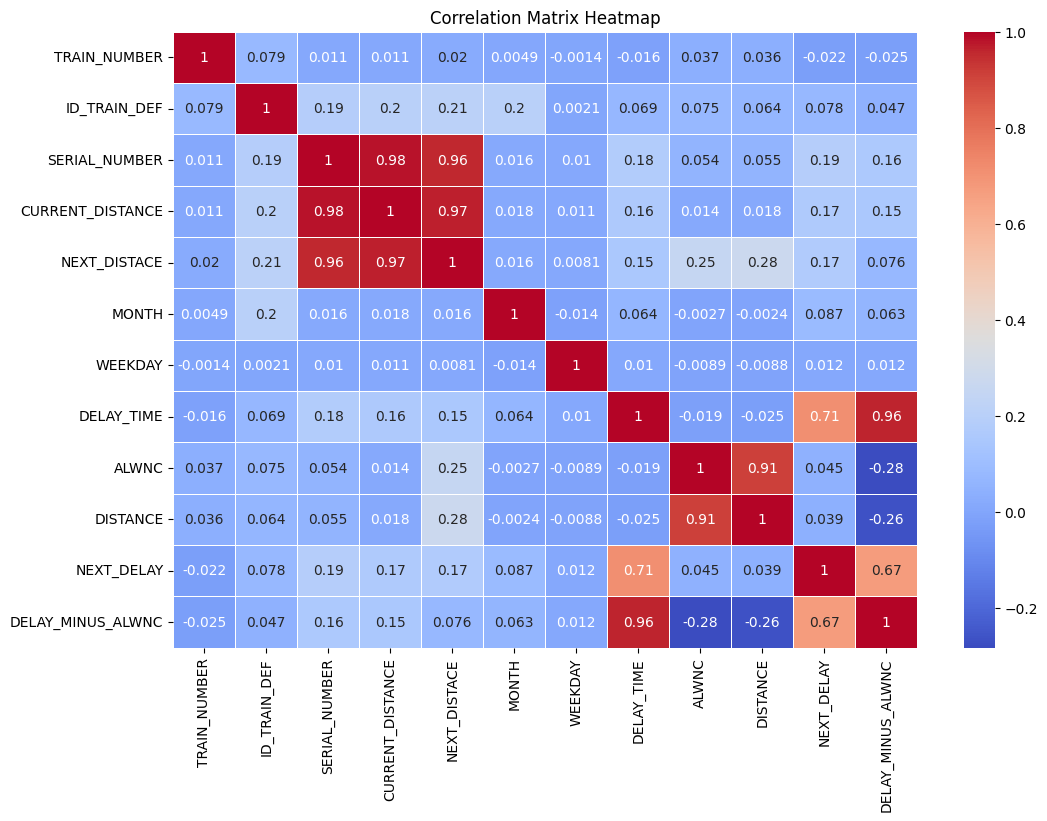

In [13]:
# Only the numeric columns are selected for correlation calculation
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = train[numeric_cols].corr()

# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

# RandomForestRegressor

In [14]:
random_forest = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_split=5, random_state=48)

# Training model
start_time = time.time()
random_forest.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
print("Training time:", training_time, "seconds")

# Testing on the test set
start_time = time.time()
y_pred_rf = random_forest.predict(X_test)
end_time = time.time()
testing_time = end_time - start_time
print("Testing time:", testing_time, "seconds")

Training time: 309.21337819099426 seconds
Testing time: 0.8342137336730957 seconds


In [15]:
# Evaluation by error metrics
r2 = r2_score(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)

print("R2 score (test set):", r2)
print("Mean Squared Error (test set):", mse)
print("Mean Absolute Error (test set):", mae)

R2 score (test set): 0.8158505798774007
Mean Squared Error (test set): 854.5634089632188
Mean Absolute Error (test set): 11.548580566039192


# XGBoost

In [16]:
xgb = XGBRegressor(n_estimators= 100, learning_rate= 0.3, max_depth= 3, random_state= 48)

# Training model
start_time = time.time()
xgb.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
print("Training time:", training_time, "seconds")

# Testing on the test set
start_time = time.time()
y_pred_xgb = xgb.predict(X_test)
end_time = time.time()
testing_time = end_time - start_time
print("Testing time:", testing_time, "seconds")

Training time: 1.817138910293579 seconds
Testing time: 0.034662723541259766 seconds


In [17]:
# Evaluation by error metrics
r2 = r2_score(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
mae = mean_absolute_error(y_test, y_pred_xgb)

print("R2 score (test set):", r2)
print("Mean Squared Error (test set):", mse)
print("Mean Absolute Error (test set):", mae)

R2 score (test set): 0.8229071497917175
Mean Squared Error (test set): 821.8167114257812
Mean Absolute Error (test set): 11.474477767944336


# LightGBM





In [18]:
lightgbm = LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=10, random_state=48, verbose =-1)

# Training model
start_time = time.time()
lightgbm.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
print("Training time:", training_time, "seconds")

# Testing on the test set
start_time = time.time()
y_pred_lgbm = lightgbm.predict(X_test)
end_time = time.time()
testing_time = end_time - start_time
print("Testing time:", testing_time, "seconds")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Training time: 1.8264548778533936 seconds
Testing time: 0.13696622848510742 seconds


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [19]:
# Evaluation by error metrics
r2 = r2_score(y_test, y_pred_lgbm)
mse = mean_squared_error(y_test, y_pred_lgbm)
mae = mean_absolute_error(y_test, y_pred_lgbm)

print("R2 score (test set):", r2)
print("Mean Squared Error (test set):", mse)
print("Mean Absolute Error (test set):", mae)

R2 score (test set): 0.8154475674238292
Mean Squared Error (test set): 856.4336277016189
Mean Absolute Error (test set): 11.19193866423065


In [20]:
# Checking for models prediction range (if not in same range then use MinMax scaling for stacking)
print("RandomForest range:", y_pred_rf.min(), y_pred_rf.max())
print("XGBoost range:", y_pred_xgb.min(), y_pred_xgb.max())
print("LightGBM range:", y_pred_lgbm.min(), y_pred_lgbm.max())


RandomForest range: 0.42308865350303165 1113.6372422063755
XGBoost range: -12.8836155 698.96875
LightGBM range: -8.298159009655345 941.3258052918591


Each model has different prediction range due to use of Standard Scalar

# Stacking : MLPRegressor

In [21]:
# Combine predictions into meta-features
meta_features = np.column_stack((y_pred_rf, y_pred_xgb, y_pred_lgbm))

# Scaling to 0-1 range
meta_scaler = MinMaxScaler()
meta_features_scaled = meta_scaler.fit_transform(meta_features)

# Train test split
X_meta_train, X_meta_test, y_meta_train, y_meta_test = train_test_split(meta_features_scaled, y_test, test_size=0.3, random_state=48)


meta_model = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', max_iter=1000, random_state=48)

# Training the meta-model
start_time = time.time()
meta_model.fit(X_meta_train, y_meta_train)
end_time = time.time()

print("Meta-Model Training Time:", end_time - start_time)

# Testing the meta-model
start_time = time.time()
final_pred = meta_model.predict(X_meta_test)
end_time = time.time()
print("Meta-Model Testing Time:", end_time - start_time)

# Evaluation by error metrics
r2 = r2_score(y_meta_test, final_pred)
mse = mean_squared_error(y_meta_test, final_pred)
mae = mean_absolute_error(y_meta_test, final_pred)

print("R2 score:",r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)


Meta-Model Training Time: 2.420332908630371
Meta-Model Testing Time: 0.00551152229309082
R2 score: 0.8519507577029037
Mean Squared Error: 722.9702344240951
Mean Absolute Error: 11.10164337009277


# Scatter Plot: Actual vs Predicted Values

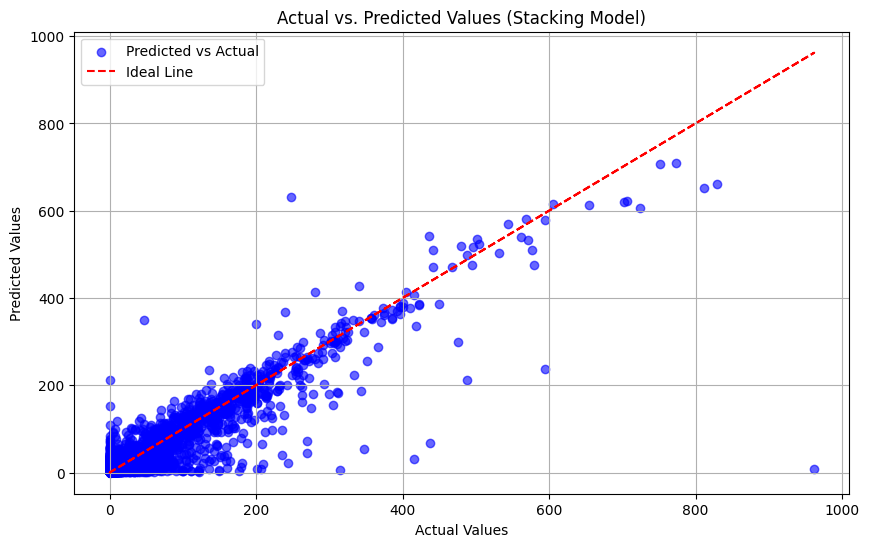

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Actual vs Predicted values
plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(y_meta_test, final_pred, color='blue', label='Predicted vs Actual', alpha=0.6)
plt.plot(y_meta_test, y_meta_test, color="red", linestyle="dashed", label="Ideal Line")  # 45-degree line
# Labels and legend
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values (Stacking Model)')
plt.legend()
plt.grid(True)
plt.show()


In [23]:
# Creating a DataFrame to compare actual vs predicted values
comparison_df = pd.DataFrame({
    'Actual Next Delay': y_meta_test,
    'Predicted Next Delay': final_pred
})

# Saving the comparison DataFrame to a CSV file
comparison_df.to_csv('actual_vs_predicted_delays.csv', index=False)

# first few rows of the DataFrame
print(comparison_df)

        Actual Next Delay  Predicted Next Delay
73067                   1              1.301926
108440                  0             16.897346
17105                   0              1.836667
76529                 182            174.033375
51930                   0              8.083925
...                   ...                   ...
100398                  0              6.543479
9294                    0              2.678839
33607                  28             48.905937
88196                   0              4.033818
35642                   0              1.403022

[6583 rows x 2 columns]


# Line Plot: Actual vs Predicted Delay over samples

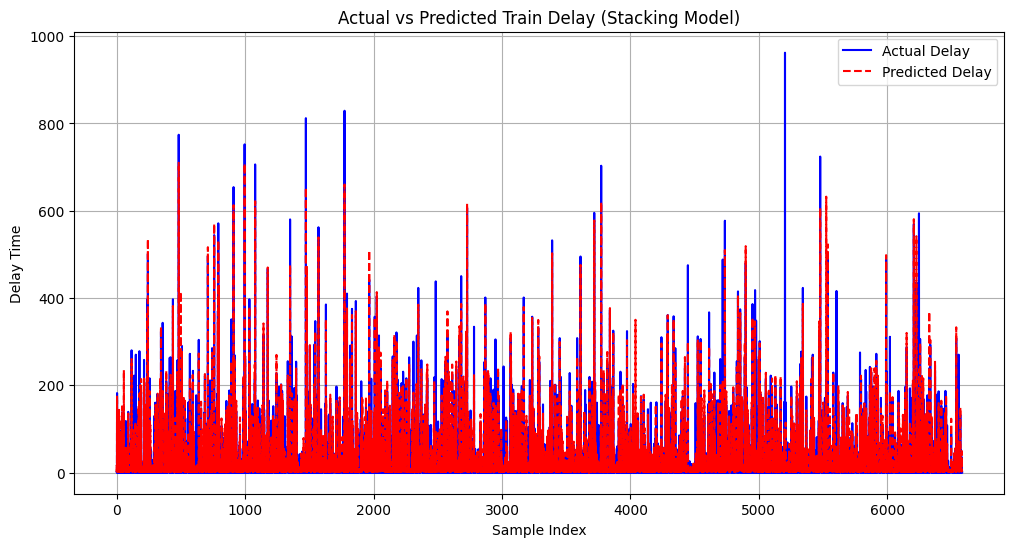

In [24]:
plt.figure(figsize=(12, 6))

# Plotting actual vs. predicted delays
plt.plot(y_meta_test.values, label='Actual Delay', color='blue')  # Using .values to remove the pandas index and converting to NumPy array to plot only the data values without index
plt.plot(final_pred, label='Predicted Delay', color='red', linestyle='--')

# Labels and legend
plt.xlabel('Sample Index')
plt.ylabel('Delay Time')
plt.title('Actual vs Predicted Train Delay (Stacking Model)')
plt.legend()
plt.grid(True)
plt.show()
